# Model 4 — Demand Forecasting

**JD bullet:** _Own the consolidated compute and infrastructure demand forecast._

**Question:** Given the historical usage trend, how many GPUs does the fleet need over the next four quarters, and what is the capital implication?

## 1. Inputs & Assumptions

- **Source:** daily `gpu_seconds` from `inference_events` (query Q4).
- **Trend model:** linear fit of daily GPU-seconds over the 12-month history (captures the engineered upward demand trend; weekly seasonality averages out at the daily-trend level).
- **GPU conversion:** `GPUs = daily_gpu_seconds / (86,400 s × target_utilisation)`, with **target_utilisation = 75%**.
- **Production scale (assumption):** sample scaled to **1B inferences/day** so the fleet size is realistic; the *growth multiple* is scale-free.
- **Capex:** **$30,000 per GPU** (assumption).
- **Scenarios:** base = fitted growth; **upside +30%**, **downside −30%** on the growth rate.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.figsize':(9,4.5),'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})
NAVY, AMBER, GREY = '#1F3864', '#E1A140', '#9AA5B1'

conn = sqlite3.connect('../data/events.db')
pd.set_option('display.float_format', lambda v: f'{v:,.6f}')
print('rows:', pd.read_sql_query('SELECT COUNT(*) n FROM inference_events', conn).n[0])

rows: 120000


## 2. Working Code

### 2a. Daily demand history and trend fit (query Q4)

fitted daily growth: 0.043 gpu-sec/day
historical growth multiple over the year: 2.39x


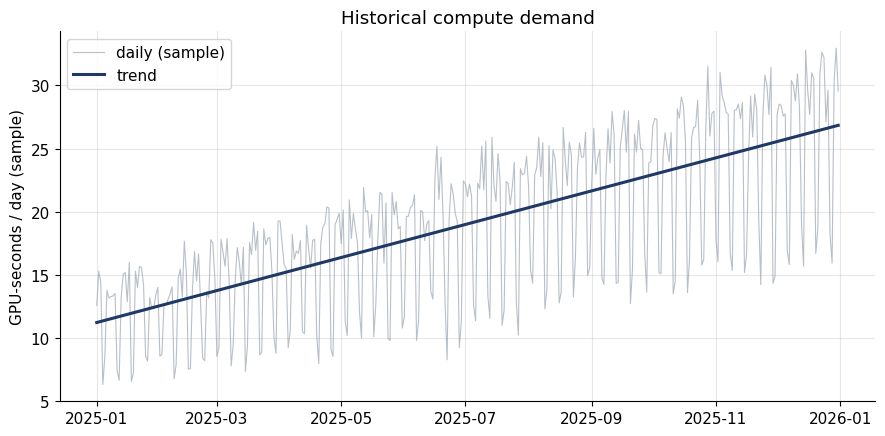

In [2]:
q = '''
SELECT DATE(e.timestamp) AS day, SUM(e.gpu_seconds) AS gpu_seconds
FROM inference_events e
GROUP BY day ORDER BY day
'''
d = pd.read_sql_query(q, conn)
d['day'] = pd.to_datetime(d.day)
d['t'] = (d.day - d.day.min()).dt.days
slope, intercept = np.polyfit(d.t, d.gpu_seconds, 1)
growth_multiple = (intercept + slope*d.t.max()) / (intercept + slope*d.t.min())
print(f'fitted daily growth: {slope:.3f} gpu-sec/day')
print(f'historical growth multiple over the year: {growth_multiple:.2f}x')

fig, ax = plt.subplots()
ax.plot(d.day, d.gpu_seconds, color=GREY, lw=0.8, alpha=0.7, label='daily (sample)')
ax.plot(d.day, intercept + slope*d.t, color=NAVY, lw=2.2, label='trend')
ax.set_ylabel('GPU-seconds / day (sample)'); ax.set_title('Historical compute demand')
ax.legend(); plt.tight_layout(); plt.show()

### 2b. Scale to production and project the fleet, four quarters out

In [3]:
events = pd.read_sql_query('SELECT COUNT(*) n FROM inference_events', conn).n[0]
SCALE = 1_000_000_000 / (events/365)     # sample -> 1B inferences/day
TARGET_UTIL, CAPEX = 0.75, 30_000
def gpus(daily_gpu_sec_sample): return daily_gpu_sec_sample*SCALE/(86_400*TARGET_UTIL)

cur_daily = intercept + slope*d.t.max()
g_now = gpus(cur_daily)
q_days = [d.t.max() + 90*q for q in range(1,5)]
rows=[]
for label, mult in [('base',1.0),('upside',1.3),('downside',0.7)]:
    for q,(qd) in enumerate(q_days,1):
        daily = cur_daily + slope*(qd-d.t.max())*mult
        rows.append({'scenario':label,'quarter':f'Q{q}','gpus':gpus(daily)})
fc = pd.DataFrame(rows)
pivot = fc.pivot(index='quarter', columns='scenario', values='gpus')[['downside','base','upside']]
print(f'current run-rate fleet: {g_now:,.0f} GPUs')
pivot.round(0)

current run-rate fleet: 1,260 GPUs


scenario,downside,base,upside
quarter,,,
Q1,"1,387.000000","1,441.000000","1,496.000000"
Q2,"1,514.000000","1,622.000000","1,731.000000"
Q3,"1,641.000000","1,804.000000","1,967.000000"
Q4,"1,767.000000","1,985.000000","2,202.000000"


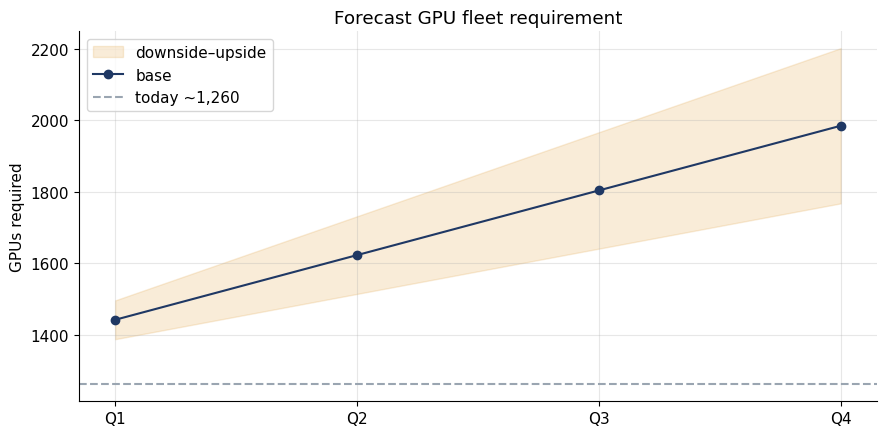

In [4]:
fig, ax = plt.subplots()
x = range(len(pivot.index))
ax.fill_between(x, pivot.downside, pivot.upside, color=AMBER, alpha=0.20, label='downside–upside')
ax.plot(x, pivot.base, '-o', color=NAVY, label='base')
ax.axhline(g_now, color=GREY, ls='--', label=f'today ~{g_now:,.0f}')
ax.set_xticks(list(x)); ax.set_xticklabels(pivot.index)
ax.set_ylabel('GPUs required'); ax.set_title('Forecast GPU fleet requirement')
ax.legend(); plt.tight_layout(); plt.show()

### 2c. Capital implication (base case, Q4)

In [5]:
add = pivot.base.iloc[-1] - g_now
capex = add * CAPEX
print(f'base case: fleet {g_now:,.0f} -> {pivot.base.iloc[-1]:,.0f} GPUs by Q4 '
      f'(+{add:,.0f} GPUs)')
print(f'capital implication @ ${CAPEX:,}/GPU: ${capex:,.0f}')
print(f'range by Q4: {pivot.downside.iloc[-1]:,.0f} (down) .. {pivot.upside.iloc[-1]:,.0f} (up) GPUs')

base case: fleet 1,260 -> 1,985 GPUs by Q4 (+725 GPUs)
capital implication @ $30,000/GPU: $21,746,502
range by Q4: 1,767 (down) .. 2,202 (up) GPUs


## 3. Insight

> **Demand compounds ~2.4× a year; the fleet must follow, and the capital ask is plannable.** Translating the historical trend forward at a representative 1B inferences/day, the fleet scales from **~1,260 GPUs to ~1,985 (base)** by Q4 — **+725 GPUs, ~$21.7M** of capital at \$30K/GPU. The scenario band runs **~1,770 (downside) to ~2,200 (upside)**.

**Why the band matters:** GPUs are long-lead, take-or-pay assets. The downside/upside spread (~430 GPUs, ~$13M) is the size of the over-/under-provisioning bet — the number that justifies staged procurement rather than a single commit.

**Feeds:** this forecast is the fixed-capacity constraint that **Model 5 (Capacity Allocation)** allocates against.